# Homework 3: Download and analyze policy-relevant data

This notebook uses the World Bank API to study a public policy question:

**Do countries that spend more on health per person tend to have higher life expectancy?**

## Part 1: Data Acquisition & Environment Preparation

In [1]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt
import numpy as np

if "pyproject.toml" not in os.listdir():
    os.chdir("../../..")

current_working_directory = os.getcwd()
print("Current working directory:", os.path.basename(current_working_directory))
print("Project directory files:", os.listdir())

data_folder = "data/hw/hw_3/mami-umeki"
os.makedirs(data_folder, exist_ok=True)

start_year = 2015
end_year = 2022

Current working directory: datascience-publicpolicy-2026
Project directory files: ['requirements.txt', 'uv.lock', 'environment.yml', 'references', 'pyproject.toml', 'docs', 'README.md', '.gitignore', '.git', 'data', 'notebooks', 'src']


In [2]:
def get_world_bank_indicator(indicator_code, value_column, start_year, end_year):
    url = f"https://api.worldbank.org/v2/country/all/indicator/{indicator_code}"
    params = {"date": f"{start_year}:{end_year}", "format": "json", "per_page": 20000}
    response = requests.get(url, params=params)
    response.raise_for_status()
    rows = response.json()[1]
    data = pd.json_normalize(rows)
    data = data[["countryiso3code", "date", "country.value", "value"]]
    data = data.rename({"countryiso3code": "country_code", "date": "year", "country.value": "country", "value": value_column}, axis=1)
    data["year"] = data["year"].astype(int)
    return data

life_expectancy = get_world_bank_indicator("SP.DYN.LE00.IN", "life_expectancy", start_year, end_year)
life_expectancy.to_csv(f"{data_folder}/world_bank_life_expectancy.csv", index=False)
life_expectancy.head()

,country_code,year,country,life_expectancy
0,AFE,2022,Africa Eastern and Southern,64.487152
1,AFE,2021,Africa Eastern and Southern,62.979999
2,AFE,2020,Africa Eastern and Southern,63.766484
3,AFE,2019,Africa Eastern and Southern,63.857261
4,AFE,2018,Africa Eastern and Southern,63.330691


### Dataset Context & Relevance

**Primary source:** World Bank API, indicator `SP.DYN.LE00.IN`, life expectancy at birth.

Life expectancy is a central public policy outcome because it summarizes health, safety, nutrition, income, and access to care. I use country-year observations from 2015 to 2022 so the dataset has far more than 50 observations.

## Part 2: Data Cleaning & Preprocessing

In [3]:
life_expectancy.info()
life_expectancy.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2128 entries, 0 to 2127
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country_code     2128 non-null   object 
 1   year             2128 non-null   int64  
 2   country          2128 non-null   object 
 3   life_expectancy  2120 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 66.6+ KB


,country_code,year,country,life_expectancy
0,AFE,2022,Africa Eastern and Southern,64.487152
1,AFE,2021,Africa Eastern and Southern,62.979999
2,AFE,2020,Africa Eastern and Southern,63.766484
3,AFE,2019,Africa Eastern and Southern,63.857261
4,AFE,2018,Africa Eastern and Southern,63.330691


In [4]:
life_column_map = {"country_code": "country_code", "year": "year", "country": "country", "life_expectancy": "life_expectancy"}
life_clean = life_expectancy.rename(life_column_map, axis=1)
life_clean = life_clean[["country_code", "year", "country", "life_expectancy"]]
life_clean.head()

,country_code,year,country,life_expectancy
0,AFE,2022,Africa Eastern and Southern,64.487152
1,AFE,2021,Africa Eastern and Southern,62.979999
2,AFE,2020,Africa Eastern and Southern,63.766484
3,AFE,2019,Africa Eastern and Southern,63.857261
4,AFE,2018,Africa Eastern and Southern,63.330691


In [5]:
life_clean = life_clean.query("year >= 2015 and year <= 2022")
print("Life expectancy rows after year filter:", life_clean.shape[0])
life_clean.head()

Life expectancy rows after year filter: 2128


,country_code,year,country,life_expectancy
0,AFE,2022,Africa Eastern and Southern,64.487152
1,AFE,2021,Africa Eastern and Southern,62.979999
2,AFE,2020,Africa Eastern and Southern,63.766484
3,AFE,2019,Africa Eastern and Southern,63.857261
4,AFE,2018,Africa Eastern and Southern,63.330691


In [6]:
life_clean = life_clean.dropna(subset=["country_code", "year", "life_expectancy"])
life_clean.info()
life_clean.head()

<class 'pandas.core.frame.DataFrame'>
Index: 2120 entries, 0 to 2127
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   country_code     2120 non-null   object 
 1   year             2120 non-null   int64  
 2   country          2120 non-null   object 
 3   life_expectancy  2120 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 82.8+ KB


,country_code,year,country,life_expectancy
0,AFE,2022,Africa Eastern and Southern,64.487152
1,AFE,2021,Africa Eastern and Southern,62.979999
2,AFE,2020,Africa Eastern and Southern,63.766484
3,AFE,2019,Africa Eastern and Southern,63.857261
4,AFE,2018,Africa Eastern and Southern,63.330691


## Part 3: Merging Datasets

The secondary dataset is also downloaded from the World Bank API. It measures current health expenditure per capita in current US dollars, indicator `SH.XPD.CHEX.PC.CD`.

In [7]:
health_spending = get_world_bank_indicator("SH.XPD.CHEX.PC.CD", "health_spending_per_capita", start_year, end_year)
health_spending.to_csv(f"{data_folder}/world_bank_health_spending.csv", index=False)
health_spending.info()
health_spending.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2128 entries, 0 to 2127
Data columns (total 4 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   country_code                2128 non-null   object 
 1   year                        2128 non-null   int64  
 2   country                     2128 non-null   object 
 3   health_spending_per_capita  1920 non-null   float64
dtypes: float64(1), int64(1), object(2)
memory usage: 66.6+ KB


,country_code,year,country,health_spending_per_capita
0,AFE,2022,Africa Eastern and Southern,92.035288
1,AFE,2021,Africa Eastern and Southern,92.350333
2,AFE,2020,Africa Eastern and Southern,81.446140
3,AFE,2019,Africa Eastern and Southern,87.039877
4,AFE,2018,Africa Eastern and Southern,89.969369


In [8]:
spending_column_map = {"country_code": "country_code", "year": "year", "country": "country", "health_spending_per_capita": "health_spending_per_capita"}
spending_clean = health_spending.rename(spending_column_map, axis=1)
spending_clean = spending_clean[["country_code", "year", "health_spending_per_capita"]]
spending_clean = spending_clean.dropna(subset=["country_code", "year", "health_spending_per_capita"])
spending_clean = spending_clean.query("health_spending_per_capita > 0")
spending_clean.head()

,country_code,year,health_spending_per_capita
0,AFE,2022,92.035288
1,AFE,2021,92.350333
2,AFE,2020,81.446140
3,AFE,2019,87.039877
4,AFE,2018,89.969369


In [9]:
def get_world_bank_countries():
    url = "https://api.worldbank.org/v2/country"
    params = {"format": "json", "per_page": 400}
    response = requests.get(url, params=params)
    response.raise_for_status()
    rows = response.json()[1]
    countries = pd.json_normalize(rows)
    countries = countries.rename({"id": "country_code", "name": "country_name", "region.value": "region", "incomeLevel.value": "income_level"}, axis=1)
    countries = countries[["country_code", "country_name", "region", "income_level"]]
    countries = countries.query("region != 'Aggregates' and income_level != 'Not classified'")
    return countries

country_metadata = get_world_bank_countries()
country_metadata.to_csv(f"{data_folder}/world_bank_country_metadata.csv", index=False)
country_metadata.head()

,country_code,country_name,region,income_level
0,ABW,Aruba,Latin America & Caribbean,High income
2,AFG,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
5,AGO,Angola,Sub-Saharan Africa,Lower middle income
6,ALB,Albania,Europe & Central Asia,Upper middle income
7,AND,Andorra,Europe & Central Asia,High income


In [10]:
merged_data = pd.merge(life_clean, spending_clean, on=["country_code", "year"], how="inner")
merged_data = pd.merge(merged_data, country_metadata, on="country_code", how="inner")
merged_data = merged_data.dropna(subset=["life_expectancy", "health_spending_per_capita", "income_level"])
print("Merged dataset shape:", merged_data.shape)
print("Countries in merged dataset:", merged_data["country_code"].nunique())
merged_data.head()

Merged dataset shape: (1523, 8)
Countries in merged dataset: 191


,country_code,year,country,life_expectancy,health_spending_per_capita,country_name,region,income_level
0,AFG,2022,Afghanistan,65.617,80.651604,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
1,AFG,2021,Afghanistan,60.417,81.521126,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
2,AFG,2020,Afghanistan,61.454,80.089233,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
3,AFG,2019,Afghanistan,62.941,74.064239,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income
4,AFG,2018,Afghanistan,62.443,71.225090,Afghanistan,"Middle East, North Africa, Afghanistan & Pakistan",Low income


### Merge Verification

**Merge key:** I merged the life expectancy and health spending datasets on `country_code` and `year`, then merged country metadata on `country_code`.

**Observations retained:** In my run, the final merged dataset kept **1,523 country-year observations** across **191 countries** after excluding World Bank aggregate regions and countries without a standard income classification.

## Part 4: Aggregation & Groupby Analysis

I group the merged data by World Bank income level. This lets me compare average life expectancy and health spending across income categories.

In [11]:
income_summary = merged_data.groupby("income_level", observed=False)[["life_expectancy", "health_spending_per_capita"]].mean().reset_index()
income_counts = merged_data.groupby("income_level", observed=False)["country_code"].count().reset_index()
income_counts = income_counts.rename({"country_code": "observations"}, axis=1)
income_summary = pd.merge(income_summary, income_counts, on="income_level", how="left")
income_summary = income_summary.sort_values("health_spending_per_capita")
income_summary

,income_level,life_expectancy,health_spending_per_capita,observations
1,Low income,60.893795,41.491789,190
2,Lower middle income,67.022638,132.821532,400
3,Upper middle income,72.621294,443.684084,421
0,High income,79.091500,3145.557110,512


### Policy Interpretation

The groupby results show a strong income gradient. High-income countries spend much more per person on health care and also have higher average life expectancy. This pattern is not causal evidence, but it is consistent with the idea that richer countries have more resources to invest in health systems and related public services.

## Part 5: Visualization & Regression Modeling

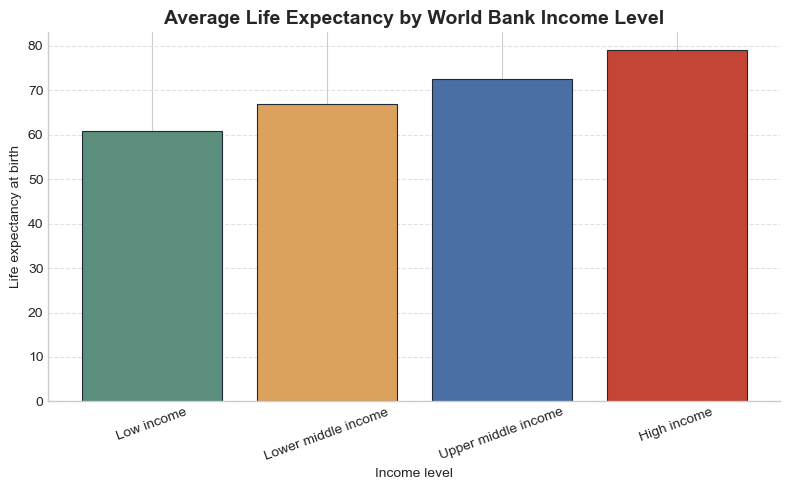

In [12]:
plt.style.use("seaborn-v0_8-whitegrid")
fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = ["#5B8E7D", "#DDA15E", "#4A6FA5", "#C44536"]
ax.bar(income_summary["income_level"], income_summary["life_expectancy"], color=bar_colors, edgecolor="#1f2933", linewidth=0.8)
ax.set_title("Average Life Expectancy by World Bank Income Level", fontsize=14, fontweight="bold")
ax.set_xlabel("Income level")
ax.set_ylabel("Life expectancy at birth")
ax.tick_params(axis="x", rotation=20)
ax.grid(axis="y", color="#d0d7de", linestyle="--", linewidth=0.8, alpha=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

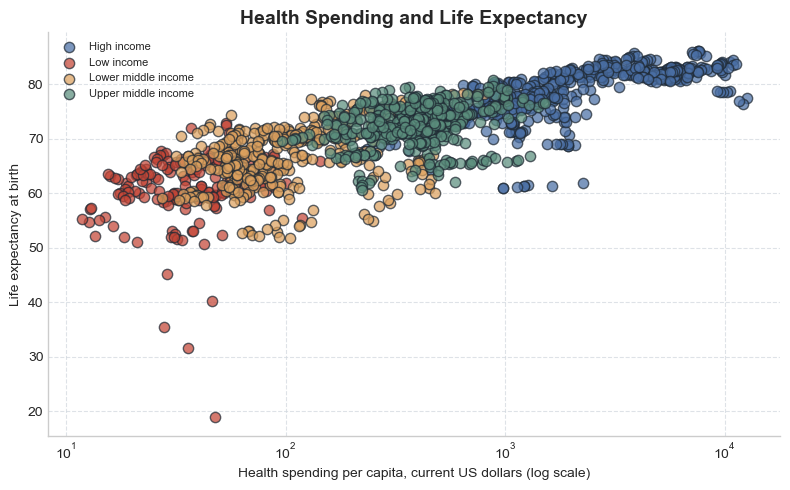

In [13]:
fig, ax = plt.subplots(figsize=(8, 5))
scatter_colors = {"Low income": "#C44536", "Lower middle income": "#DDA15E", "Upper middle income": "#5B8E7D", "High income": "#4A6FA5"}
for income_level, plot_data in merged_data.groupby("income_level"):
    ax.scatter(plot_data["health_spending_per_capita"], plot_data["life_expectancy"], color=scatter_colors.get(income_level, "#555555"), edgecolor="#1f2933", s=55, alpha=0.72, label=income_level)
ax.set_xscale("log")
ax.set_title("Health Spending and Life Expectancy", fontsize=14, fontweight="bold")
ax.set_xlabel("Health spending per capita, current US dollars (log scale)")
ax.set_ylabel("Life expectancy at birth")
ax.legend(frameon=False, fontsize=8)
ax.grid(color="#d0d7de", linestyle="--", linewidth=0.8, alpha=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:        life_expectancy   R-squared:                       0.674
Model:                            OLS   Adj. R-squared:                  0.674
Method:                 Least Squares   F-statistic:                     3148.
Date:                Thu, 18 Jun 2026   Prob (F-statistic):               0.00
Time:                        17:56:28   Log-Likelihood:                -4463.7
No. Observations:                1523   AIC:                             8931.
Df Residuals:                    1521   BIC:                             8942.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  48.1874    

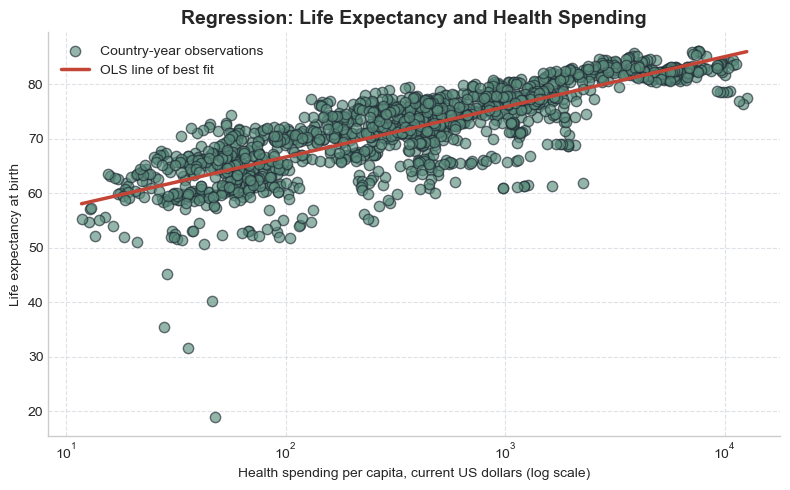

In [14]:
regression_data = merged_data.copy()
regression_data["log_health_spending"] = np.log(regression_data["health_spending_per_capita"])
regression_data = regression_data.dropna(subset=["log_health_spending", "life_expectancy"])

import statsmodels.api as sm
x_variables = sm.add_constant(regression_data["log_health_spending"])
life_expectancy_model = sm.OLS(regression_data["life_expectancy"], x_variables).fit()
print(life_expectancy_model.summary())

sorted_regression_data = regression_data.sort_values("health_spending_per_capita")
predicted_life_expectancy = life_expectancy_model.predict(sm.add_constant(sorted_regression_data["log_health_spending"]))

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(regression_data["health_spending_per_capita"], regression_data["life_expectancy"], color="#5B8E7D", edgecolor="#1f2933", s=55, alpha=0.65, label="Country-year observations")
ax.plot(sorted_regression_data["health_spending_per_capita"], predicted_life_expectancy, color="#C44536", linewidth=2.5, label="OLS line of best fit")
ax.set_xscale("log")
ax.set_title("Regression: Life Expectancy and Health Spending", fontsize=14, fontweight="bold")
ax.set_xlabel("Health spending per capita, current US dollars (log scale)")
ax.set_ylabel("Life expectancy at birth")
ax.legend(frameon=False)
ax.grid(color="#d0d7de", linestyle="--", linewidth=0.8, alpha=0.7)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

### Visualization and Regression Interpretation

The bar chart shows that average life expectancy rises with World Bank income level. The scatter plot shows a positive relationship between health spending per person and life expectancy, although countries are still spread out within each income group. The regression estimates the association between log health spending per capita and life expectancy. A positive slope means that countries with higher health spending per person tend to have higher life expectancy. This is an exploratory relationship, not proof that spending alone causes longer lives, because income, education, environment, public health systems, and many other factors also matter.